# Missing Stocks Per Tick Analysis

This notebook visualizes how many stocks are missing from each tick, given that the goal is to have all 42 possible companies present in every tick.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

## Load Stock Data

In [2]:
# Load the merged run data
merged_file = Path('runs/merged/json/merged-1-20291.json')

with open(merged_file, 'r') as f:
    data = json.load(f)

runData = data['runData']

print(f"Total events in merged data: {len(runData)}")
print(f"\nEvent types: ", end="")

# Count event types
event_types = {}
for event in runData:
    if isinstance(event, list) and len(event) > 0:
        event_type = event[0]
        event_types[event_type] = event_types.get(event_type, 0) + 1

print(event_types)

Total events in merged data: 406

Event types: {'unpaused-game': 1, 'game-started': 1, 'paused-game': 1, 'game-ended': 1, 'controller-shutdown': 1, 'controller-restart': 1, 'timer-tick': 400}


In [3]:
# Extract all ticks and their stocks
ticks_data = []
all_stock_ids = set()

for event in runData:
    if isinstance(event, list) and len(event) > 1 and event[0] == 'timer-tick':
        tick_info = event[1]
        if isinstance(tick_info, dict) and 'stocks' in tick_info:
            stocks = tick_info.get('stocks', {})
            tick_number = tick_info.get('tick', tick_info.get('tickNumber'))
            
            stock_ids = set(stocks.keys())
            all_stock_ids.update(stock_ids)
            
            ticks_data.append({
                'tick': tick_number,
                'stocks_present': len(stock_ids),
                'stock_ids': stock_ids
            })

print(f"Total unique stock IDs across all ticks: {len(all_stock_ids)}")
print(f"Total ticks: {len(ticks_data)}")
print(f"\nAll stock IDs: {sorted([int(id) for id in all_stock_ids])}")


Total unique stock IDs across all ticks: 42
Total ticks: 400

All stock IDs: [45, 232, 280, 282, 283, 284, 287, 288, 289, 290, 291, 292, 297, 298, 300, 301, 302, 303, 304, 305, 306, 307, 1595, 1667, 1671, 1673, 1675, 1677, 1679, 1681, 1683, 1685, 1687, 1689, 1691, 1693, 1695, 1697, 1699, 1701, 1703, 1705]


## Calculate Missing Stocks Per Tick

In [4]:
# Total expected stocks (all 42 unique stocks)
total_expected_stocks = len(all_stock_ids)

# Create a dataframe with missing stock information
analysis_data = []
for tick_data in ticks_data:
    stocks_present = tick_data['stocks_present']
    missing = total_expected_stocks - stocks_present
    missing_pct = (missing / total_expected_stocks) * 100
    
    analysis_data.append({
        'tick': tick_data['tick'],
        'stocks_present': stocks_present,
        'stocks_missing': missing,
        'missing_percentage': missing_pct
    })

df = pd.DataFrame(analysis_data)

print(f"Expected stocks per tick: {total_expected_stocks}")
print(f"\nDataframe shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head(10))

Expected stocks per tick: 42

Dataframe shape: (400, 4)

First few rows:
  tick  stocks_present  stocks_missing  missing_percentage
0  121              42               0                 0.0
1  122              42               0                 0.0
2  123              42               0                 0.0
3  124              42               0                 0.0
4  125              42               0                 0.0
5  126              42               0                 0.0
6  127              42               0                 0.0
7  128              42               0                 0.0
8  129              42               0                 0.0
9  130              42               0                 0.0


## Create Visualization of Missing Stocks

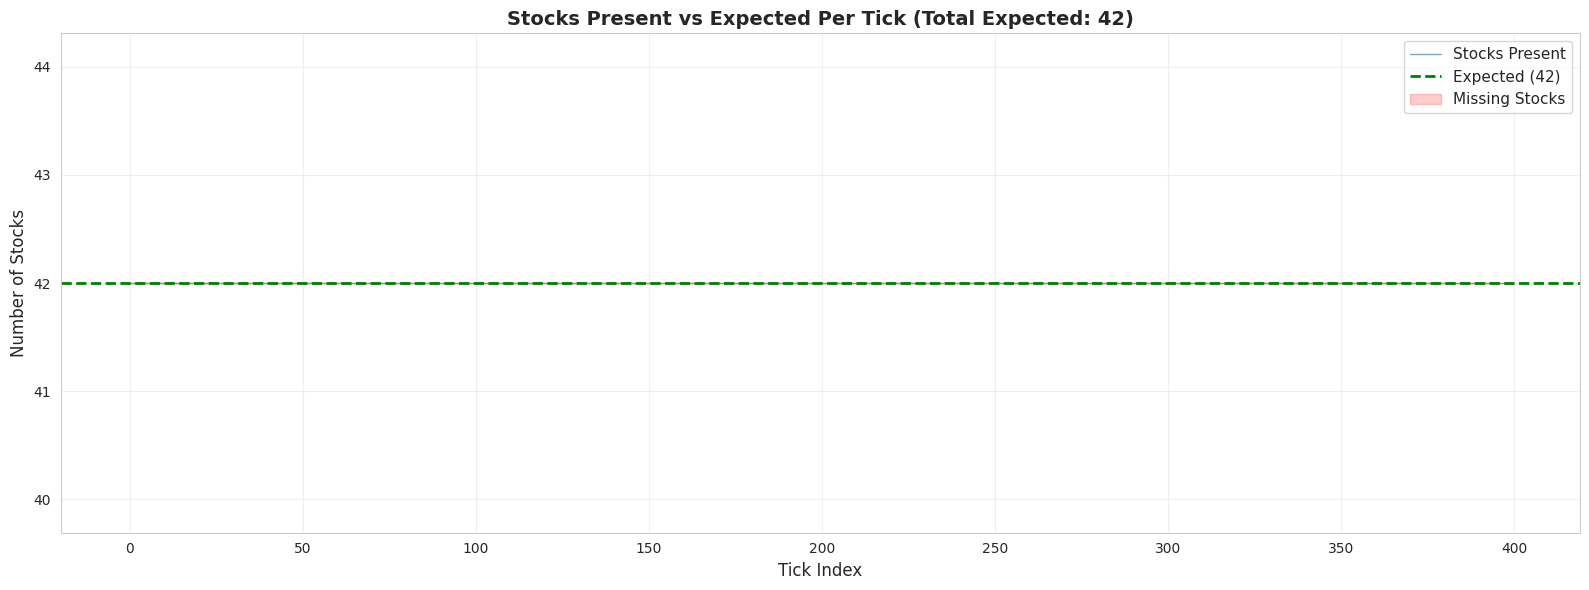

Total ticks: 400


In [6]:
# Create a line plot showing stocks present per tick
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(df)), df['stocks_present'], linewidth=1, alpha=0.7, color='steelblue', label='Stocks Present')
ax.axhline(y=total_expected_stocks, color='green', linestyle='--', linewidth=2, label=f'Expected ({total_expected_stocks})')
ax.fill_between(range(len(df)), df['stocks_present'], total_expected_stocks, alpha=0.2, color='red', label='Missing Stocks')

ax.set_xlabel('Tick Index', fontsize=12)
ax.set_ylabel('Number of Stocks', fontsize=12)
ax.set_title(f'Stocks Present vs Expected Per Tick (Total Expected: {total_expected_stocks})', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total ticks: {len(df)}")

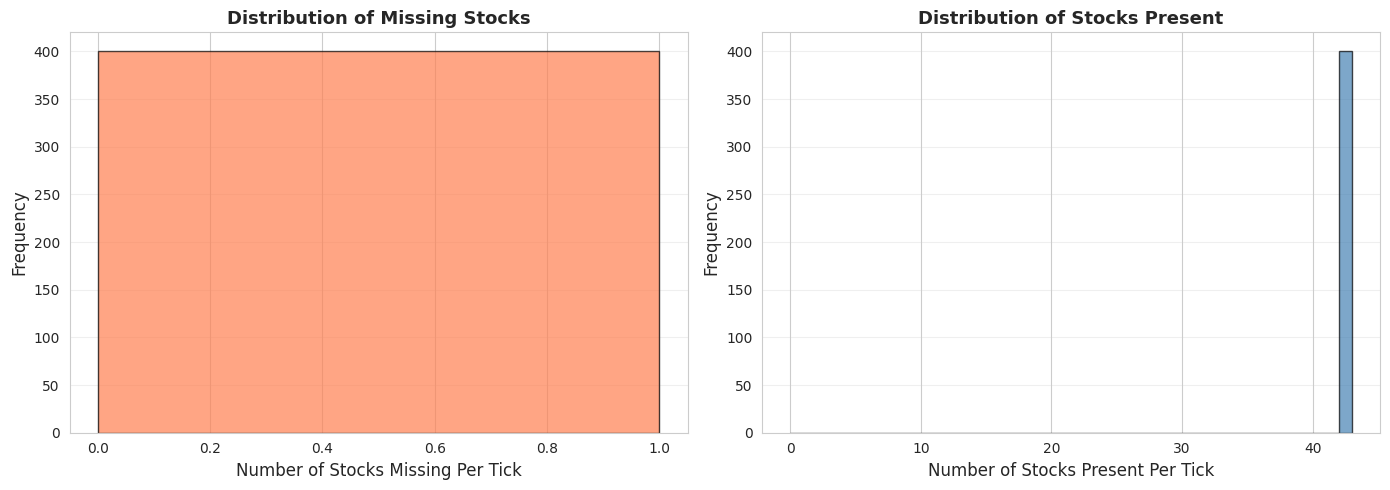

In [7]:
# Histogram of missing stocks distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of stocks missing
ax1.hist(df['stocks_missing'], bins=range(0, df['stocks_missing'].max() + 2), 
         edgecolor='black', alpha=0.7, color='coral')
ax1.set_xlabel('Number of Stocks Missing Per Tick', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Distribution of Missing Stocks', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')

# Histogram of stocks present
ax2.hist(df['stocks_present'], bins=range(0, df['stocks_present'].max() + 2), 
         edgecolor='black', alpha=0.7, color='steelblue')
ax2.set_xlabel('Number of Stocks Present Per Tick', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.set_title('Distribution of Stocks Present', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Generate Summary Statistics

In [8]:
print("=" * 70)
print("SUMMARY STATISTICS: MISSING STOCKS PER TICK")
print("=" * 70)
print(f"\nTotal Expected Stocks: {total_expected_stocks}")
print(f"Total Ticks: {len(df)}\n")

print("STOCKS MISSING:")
print(f"  Mean:   {df['stocks_missing'].mean():.2f} stocks/tick")
print(f"  Median: {df['stocks_missing'].median():.0f} stocks/tick")
print(f"  Min:    {df['stocks_missing'].min():.0f} stocks/tick")
print(f"  Max:    {df['stocks_missing'].max():.0f} stocks/tick")
print(f"  Std:    {df['stocks_missing'].std():.2f}")

print("\nSTOCKS PRESENT:")
print(f"  Mean:   {df['stocks_present'].mean():.2f} stocks/tick")
print(f"  Median: {df['stocks_present'].median():.0f} stocks/tick")
print(f"  Min:    {df['stocks_present'].min():.0f} stocks/tick")
print(f"  Max:    {df['stocks_present'].max():.0f} stocks/tick")

print("\nMISSING PERCENTAGE:")
print(f"  Mean:   {df['missing_percentage'].mean():.2f}%")
print(f"  Median: {df['missing_percentage'].median():.2f}%")
print(f"  Min:    {df['missing_percentage'].min():.2f}%")
print(f"  Max:    {df['missing_percentage'].max():.2f}%")

print("\n" + "=" * 70)

SUMMARY STATISTICS: MISSING STOCKS PER TICK

Total Expected Stocks: 42
Total Ticks: 400

STOCKS MISSING:
  Mean:   0.00 stocks/tick
  Median: 0 stocks/tick
  Min:    0 stocks/tick
  Max:    0 stocks/tick
  Std:    0.00

STOCKS PRESENT:
  Mean:   42.00 stocks/tick
  Median: 42 stocks/tick
  Min:    42 stocks/tick
  Max:    42 stocks/tick

MISSING PERCENTAGE:
  Mean:   0.00%
  Median: 0.00%
  Min:    0.00%
  Max:    0.00%



## Identify Problem Ticks

In [9]:
# Find ticks with most missing stocks
worst_ticks = df.nlargest(10, 'stocks_missing')[['tick', 'stocks_present', 'stocks_missing', 'missing_percentage']]
print("\nTOP 10 TICKS WITH MOST MISSING STOCKS:")
print(worst_ticks.to_string())

# Find ticks with all stocks (if any)
perfect_ticks = df[df['stocks_missing'] == 0]
print(f"\n\nTicks with ALL {total_expected_stocks} stocks present: {len(perfect_ticks)}")
if len(perfect_ticks) > 0:
    print(perfect_ticks[['tick', 'stocks_present']].to_string())


TOP 10 TICKS WITH MOST MISSING STOCKS:
  tick  stocks_present  stocks_missing  missing_percentage
0  121              42               0                 0.0
1  122              42               0                 0.0
2  123              42               0                 0.0
3  124              42               0                 0.0
4  125              42               0                 0.0
5  126              42               0                 0.0
6  127              42               0                 0.0
7  128              42               0                 0.0
8  129              42               0                 0.0
9  130              42               0                 0.0


Ticks with ALL 42 stocks present: 400
    tick  stocks_present
0    121              42
1    122              42
2    123              42
3    124              42
4    125              42
5    126              42
6    127              42
7    128              42
8    129              42
9    130             

/tmp/ipykernel_76073/2989372672.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_data = ax.boxplot([df['stocks_missing']], labels=['Missing Stocks'], patch_artist=True)


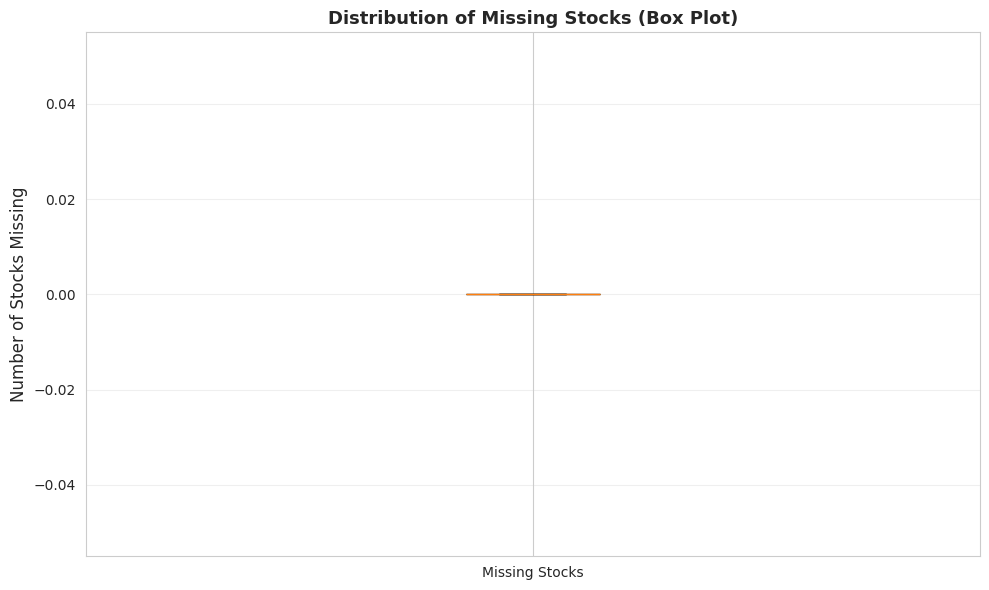


Interquartile Range (IQR): 0
Lower Quartile (Q1): 0
Upper Quartile (Q3): 0


In [10]:
# Box plot of missing stocks
fig, ax = plt.subplots(figsize=(10, 6))

box_data = ax.boxplot([df['stocks_missing']], labels=['Missing Stocks'], patch_artist=True)
for patch in box_data['boxes']:
    patch.set_facecolor('lightcoral')

ax.set_ylabel('Number of Stocks Missing', fontsize=12)
ax.set_title('Distribution of Missing Stocks (Box Plot)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nInterquartile Range (IQR): {df['stocks_missing'].quantile(0.75) - df['stocks_missing'].quantile(0.25):.0f}")
print(f"Lower Quartile (Q1): {df['stocks_missing'].quantile(0.25):.0f}")
print(f"Upper Quartile (Q3): {df['stocks_missing'].quantile(0.75):.0f}")

In [11]:
# Add this cell to your notebook
# Find which ticks are missing stocks
incomplete_ticks = df[df['stocks_missing'] > 0].sort_values('stocks_missing', ascending=False)
print(f"\nTicks with missing stocks: {len(incomplete_ticks)}")
print(incomplete_ticks[['tick', 'stocks_present', 'stocks_missing', 'missing_percentage']])

# Check if there's a pattern by tick number
print("\n\nTick numbers with issues:")
print(sorted(incomplete_ticks['tick'].tolist()))


Ticks with missing stocks: 0
Empty DataFrame
Columns: [tick, stocks_present, stocks_missing, missing_percentage]
Index: []


Tick numbers with issues:
[]
